# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
# StandardScaler  : scales features to zero mean and unit variance
# KMeans          : K-Means clustering — partitions data into k spherical clusters
# DBSCAN          : Density-Based Spatial Clustering — finds arbitrarily shaped
#                   clusters and marks outliers as noise (label = -1)
# silhouette_score: measures cluster separation quality (-1 to +1, higher = better)
# davies_bouldin_score : measures avg similarity between clusters (lower = better)

# Task 1 — Data Preprocessing & Exploratory Data Analysis (EDA)

In [2]:
# DATA LOADING
df = pd.read_excel("EastWestAirlines.xlsx", sheet_name="data")
print("Dataset loaded successfully.")
print(f"Shape : {df.shape}  ({df.shape[0]} airline members, {df.shape[1]} columns)")


Dataset loaded successfully.
Shape : (3999, 12)  (3999 airline members, 12 columns)


In [3]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [5]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [6]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


In [7]:
print(f"Duplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True, ignore_index=True)
print(f"Shape after dedup: {df.shape}")

Duplicate rows: 0
Shape after dedup: (3999, 12)


# VISUALISATION 1 — Initial Scatter: Balance vs Bonus_miles

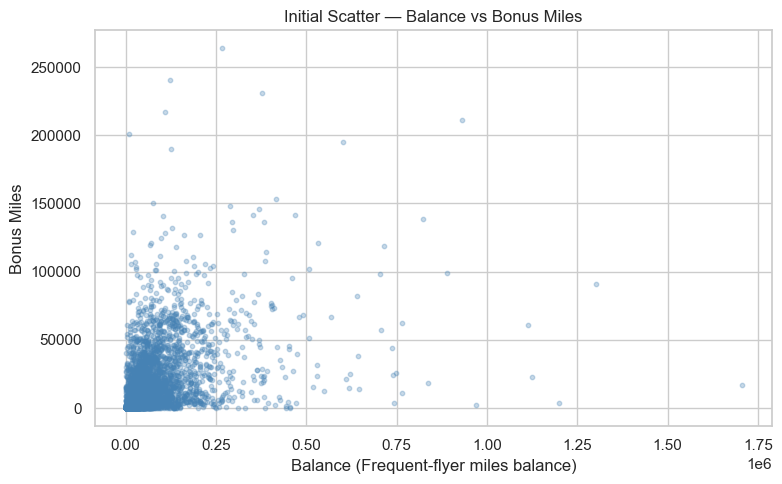

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Balance"], df["Bonus_miles"], alpha=0.3, s=10, color="steelblue")
plt.xlabel("Balance (Frequent-flyer miles balance)")
plt.ylabel("Bonus Miles")
plt.title("Initial Scatter — Balance vs Bonus Miles")
plt.tight_layout()
plt.show()

# VISUALISATION 2 — Histograms with KDE for all features

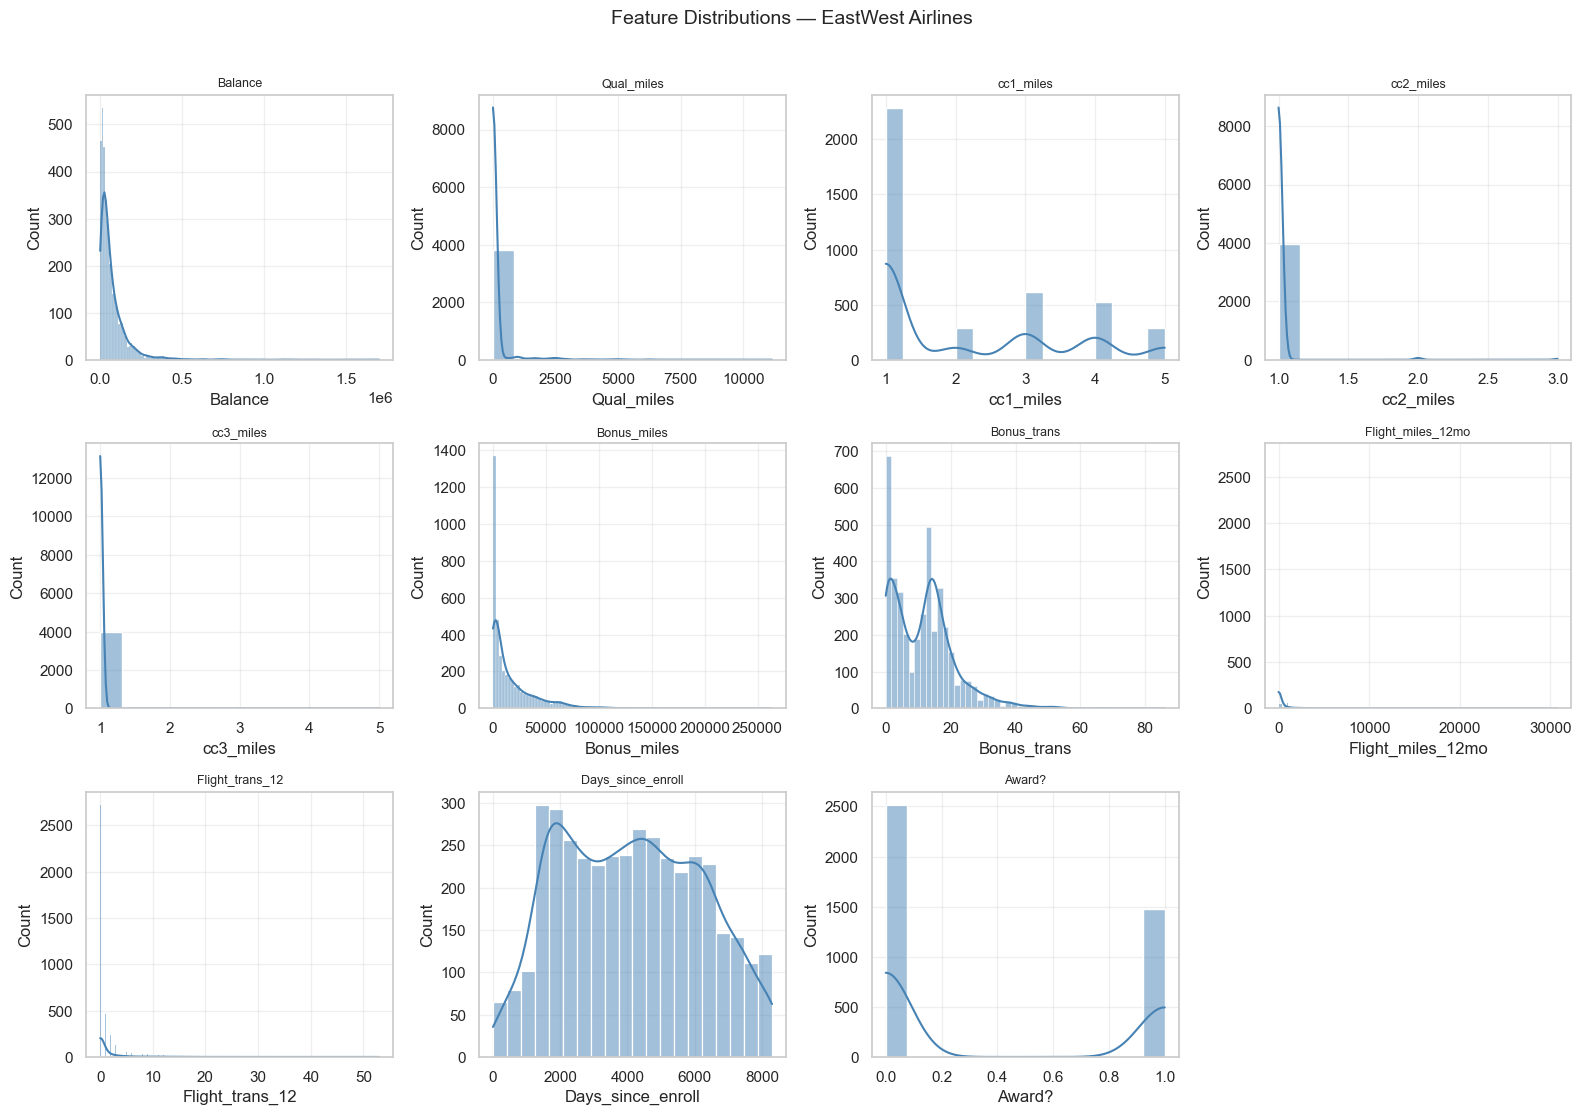

In [9]:
num_cols = [c for c in df.columns if c != "ID#"]

plt.figure(figsize=(16, 14))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df[col], kde=True, color="steelblue")
    plt.title(col, fontsize=9)
    plt.grid(True, alpha=0.3)
plt.suptitle("Feature Distributions — EastWest Airlines", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
# Reveals right-skewed distributions (Balance, Bonus_miles, Proline) and confirming outlier capping is needed. Also shows the wide range,of scales across features confirming StandardScaler is essential. 

# VISUALISATION 3 — Box Plots BEFORE Outlier Capping

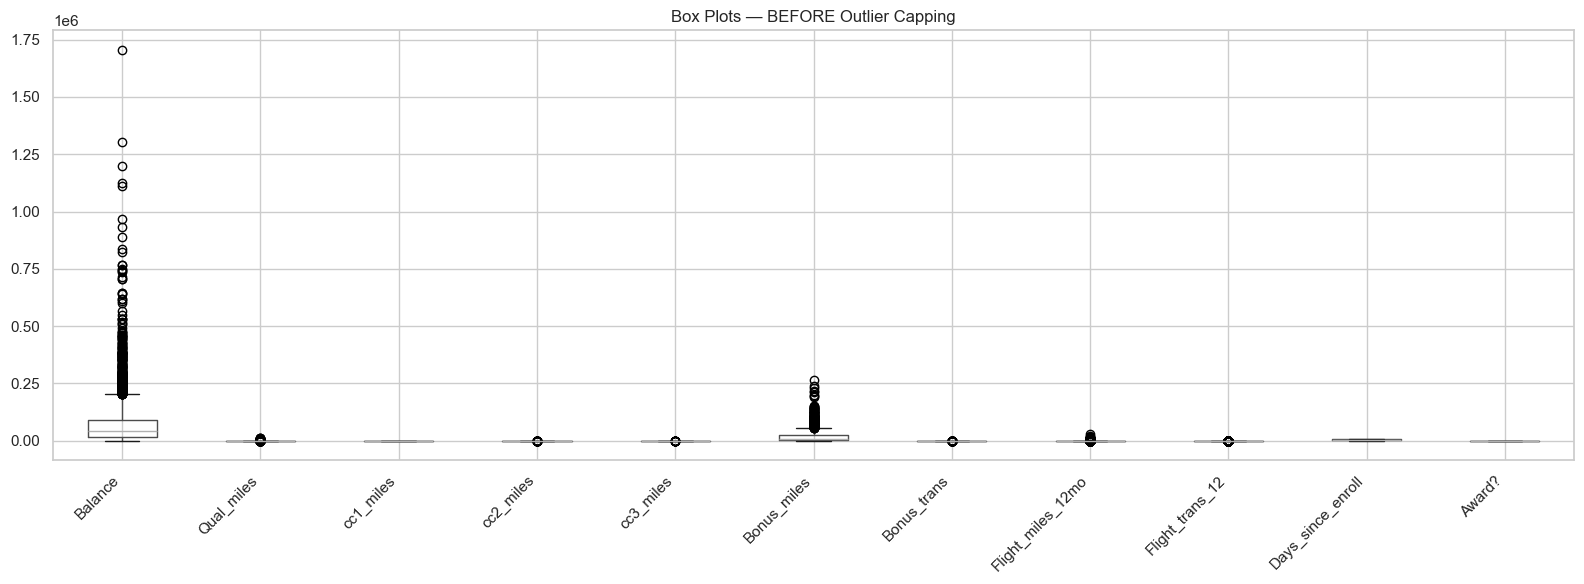

In [10]:
numeric_df = df.select_dtypes(include=["int64", "float64"]).drop(columns=["ID#"])

plt.figure(figsize=(16, 6))
numeric_df.boxplot()
plt.title("Box Plots — BEFORE Outlier Capping")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
# K-Means minimises within-cluster variance. Extreme outliers in Balance, Bonus_miles, or Flight_miles_12mo pull centroids far from the bulk of data, creating meaningless clusters.

In [11]:
# OUTLIER CAPPING (IQR Method)
def outlier_capping(df, column):
    """Caps outliers in a numeric column using the IQR fence method (in-place)."""
    q1  = df[column].quantile(0.25)
    q3  = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    df[column] = df[column].apply(
        lambda x: lower_fence if x < lower_fence
                  else upper_fence if x > upper_fence
                  else x
    )

feature_cols = [c for c in numeric_df.columns]
for col in feature_cols:
    outlier_capping(df, col)

print("Outlier capping applied to all numeric feature columns.")


Outlier capping applied to all numeric feature columns.


# VISUALISATION 4 — Box Plots AFTER Outlier Capping

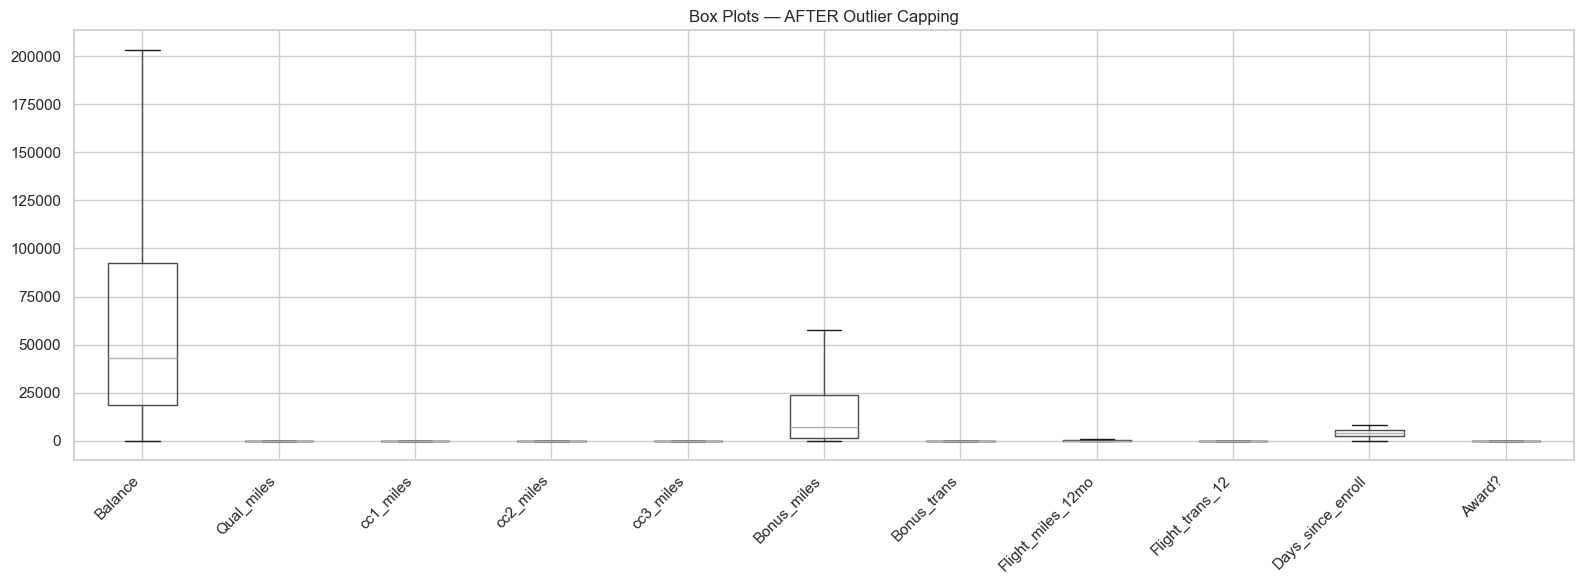

In [12]:
plt.figure(figsize=(16, 6))
df[feature_cols].boxplot()
plt.title("Box Plots — AFTER Outlier Capping")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# VISUALISATION 5 — Individual Vertical Box Plots per Feature

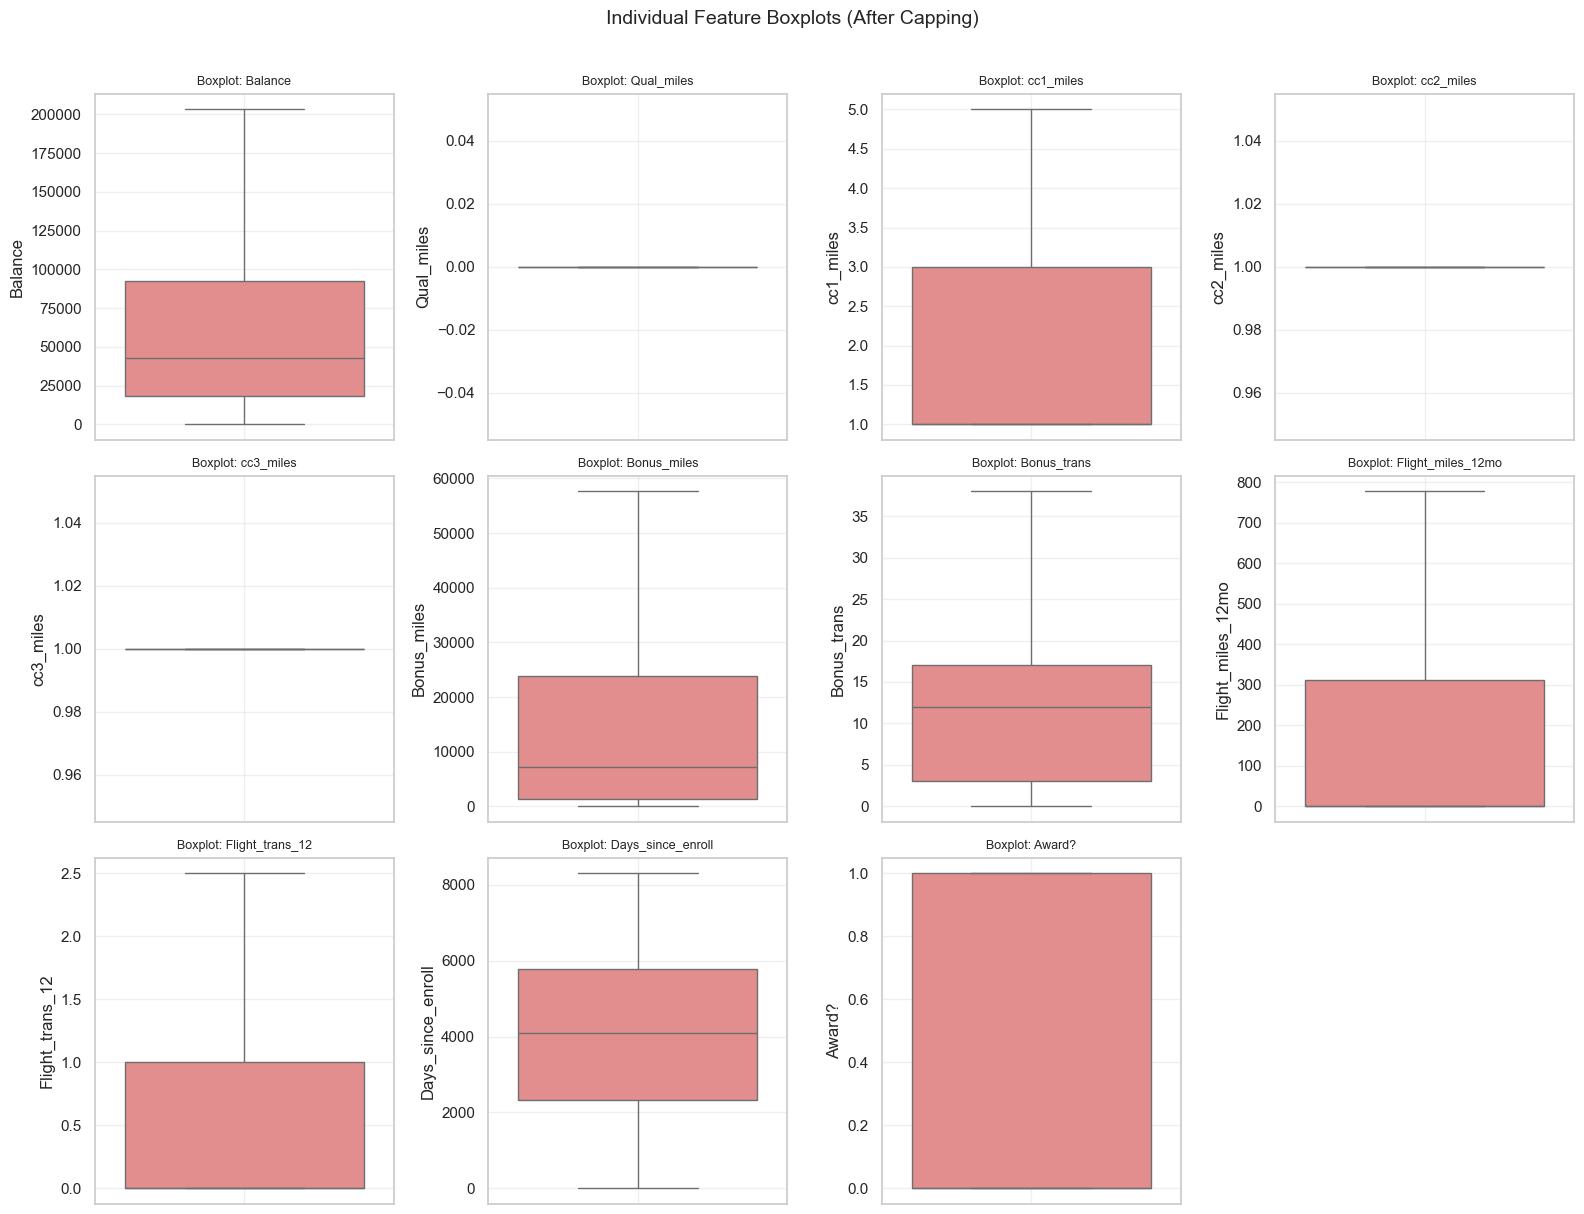

In [13]:
plt.figure(figsize=(16, 12))
for i, col in enumerate(feature_cols, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=df[col], color="lightcoral")
    plt.title(f"Boxplot: {col}", fontsize=9)
    plt.grid(True, alpha=0.3)
plt.suptitle("Individual Feature Boxplots (After Capping)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# VISUALISATION 6 — Correlation Heatmap

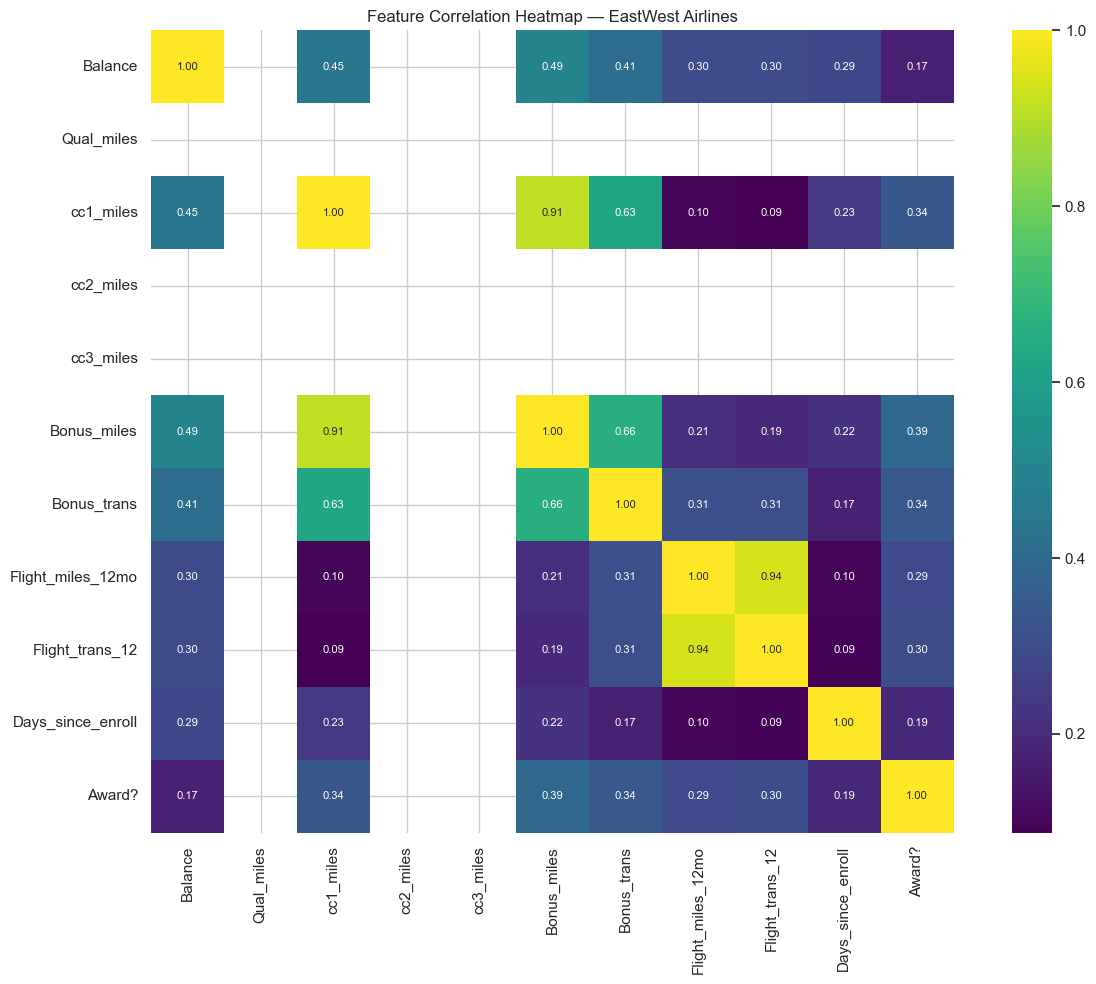

In [14]:
corr = df[feature_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, cmap="viridis", fmt=".2f",
            square=True, annot_kws={"size": 8})
plt.title("Feature Correlation Heatmap — EastWest Airlines")
plt.tight_layout()
plt.show()

# VISUALISATION 7 — Pair Plot (key features)

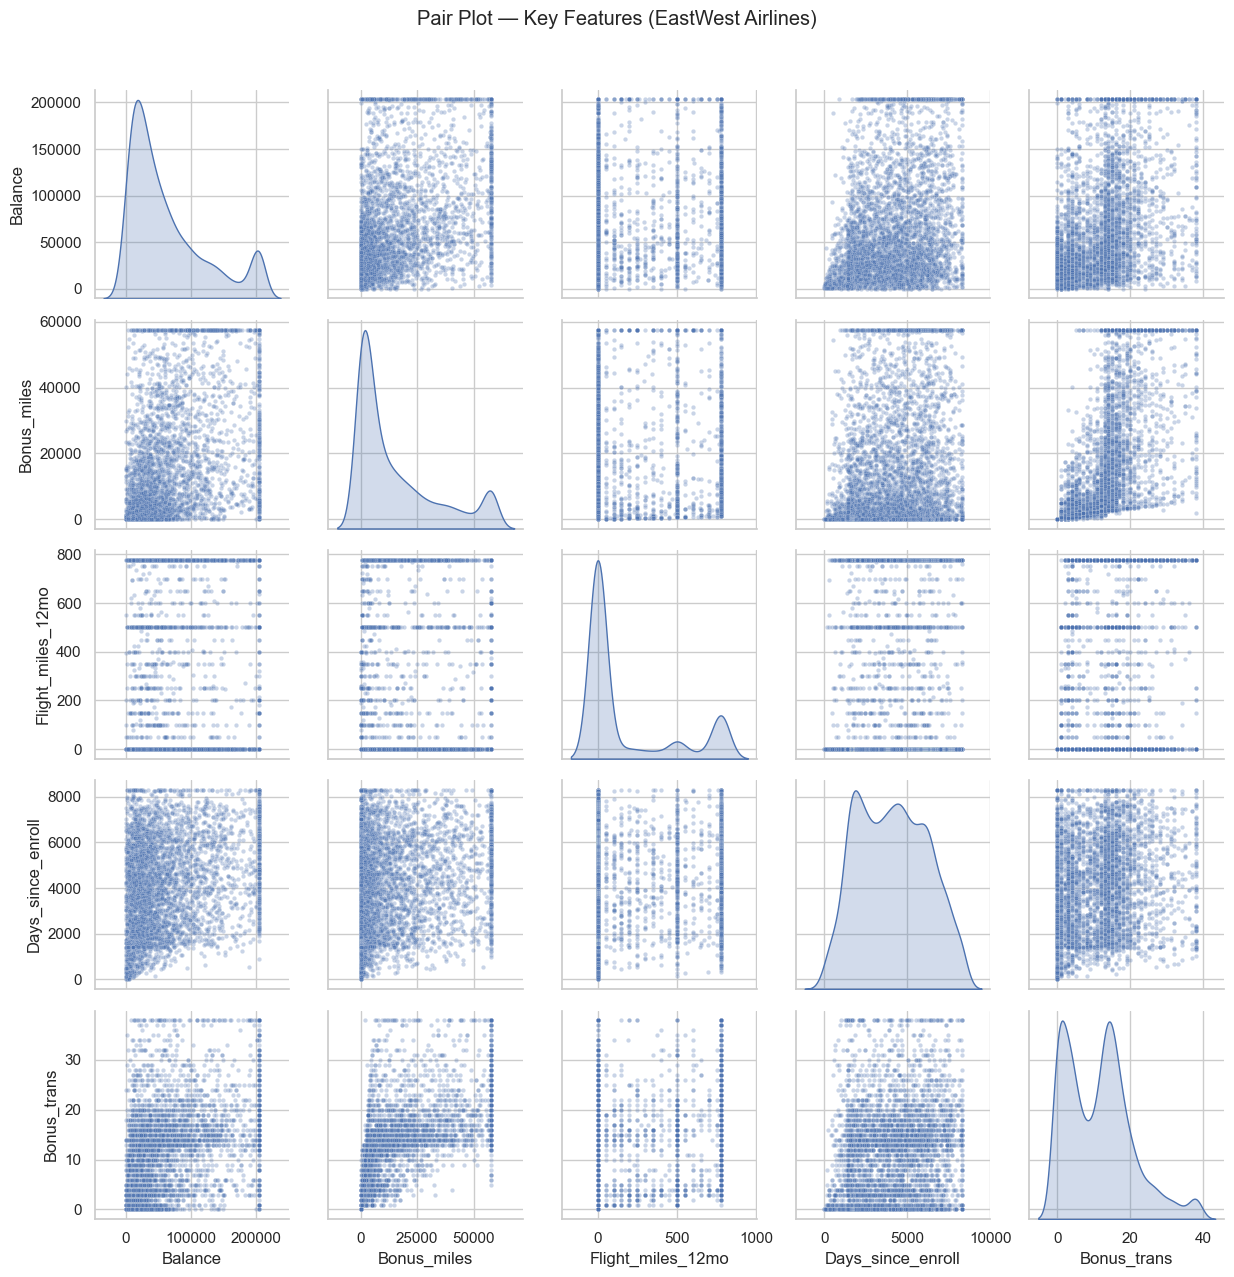

In [15]:
key_features = ["Balance", "Bonus_miles", "Flight_miles_12mo",
                "Days_since_enroll", "Bonus_trans"]

sns.pairplot(df[key_features], diag_kind="kde",
             plot_kws={"alpha": 0.3, "s": 10})
plt.suptitle("Pair Plot — Key Features (EastWest Airlines)", y=1.02)
plt.tight_layout()
plt.show()

# Task 2 — Data Preprocessing (Scaling & Feature Preparation)

In [16]:
# HANDLE MISSING VALUES — Median Imputation
missing_before = df[feature_cols].isnull().sum().sum()
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())
print(f"Missing values before imputation : {missing_before}")
print(f"Missing values after  imputation : {df[feature_cols].isnull().sum().sum()}")

Missing values before imputation : 0
Missing values after  imputation : 0


In [17]:
# Drop the ID because this column — it is a row identifier, not a feature.
features = df[feature_cols].copy()
print(f"Feature matrix shape : {features.shape}")
print(f"Features used        : {feature_cols}")

Feature matrix shape : (3999, 11)
Features used        : ['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll', 'Award?']


In [18]:
# FEATURE SCALING — StandardScaler (Z-score Normalisation)
scaler  = StandardScaler()
featss  = pd.DataFrame(scaler.fit_transform(features), columns=feature_cols)

print("Scaling complete.")
print(f"Scaled feature means  (should be ~0) : {featss.mean().round(3).values}")
print(f"Scaled feature stds   (should be ~1) : {featss.std().round(3).values}")

Scaling complete.
Scaled feature means  (should be ~0) : [-0.  0.  0.  0.  0. -0.  0. -0.  0.  0.  0.]
Scaled feature stds   (should be ~1) : [1. 0. 1. 0. 0. 1. 1. 1. 1. 1. 1.]


# Task 3 — K-Means Clustering

  k= 2  |  WCSS=22,259  |  Silhouette=0.3191
  k= 3  |  WCSS=17,646  |  Silhouette=0.3087
  k= 4  |  WCSS=15,198  |  Silhouette=0.3071
  k= 5  |  WCSS=13,695  |  Silhouette=0.2804
  k= 6  |  WCSS=12,408  |  Silhouette=0.2412
  k= 7  |  WCSS=11,414  |  Silhouette=0.2468
  k= 8  |  WCSS=10,731  |  Silhouette=0.2505
  k= 9  |  WCSS=10,034  |  Silhouette=0.2545
  k=10  |  WCSS=9,526  |  Silhouette=0.2601
  k=11  |  WCSS=9,084  |  Silhouette=0.2594


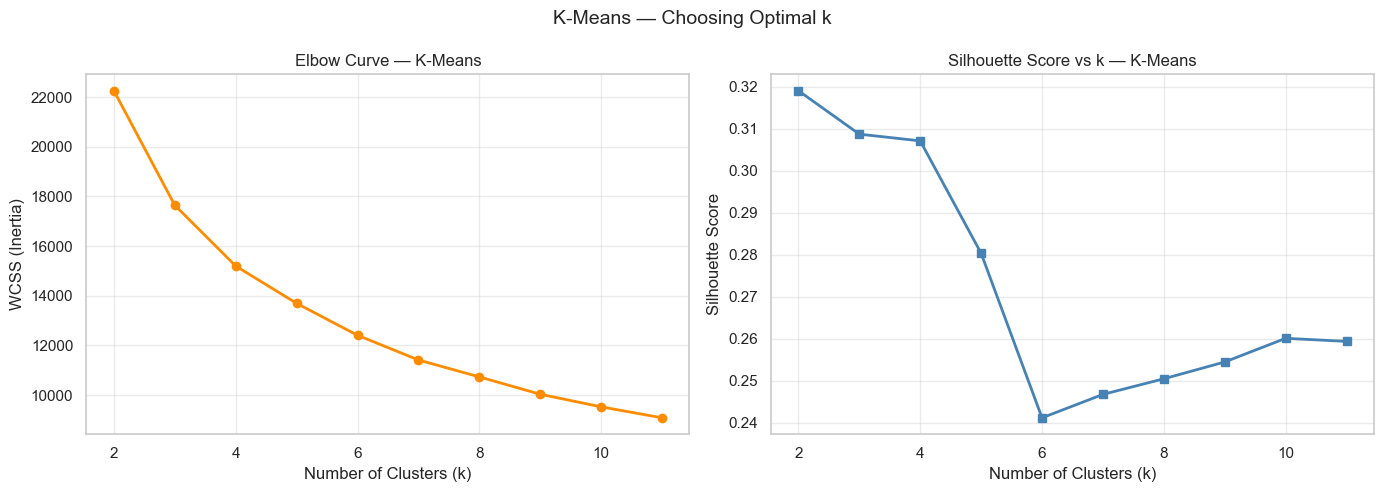


Best k by Silhouette Score: 2  (score=0.3191)


In [19]:
# ELBOW METHOD — Choosing the Optimal k
wcss       = []
sil_scores = []
k_range    = range(2, 12)

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(featss)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(featss, labels))
    print(f"  k={k:2d}  |  WCSS={km.inertia_:,.0f}  |  Silhouette={sil_scores[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(k_range, wcss, marker="o", color="darkorange", linewidth=2)
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("WCSS (Inertia)")
axes[0].set_title("Elbow Curve — K-Means")
axes[0].grid(True, alpha=0.4)

# Silhouette curve
axes[1].plot(k_range, sil_scores, marker="s", color="steelblue", linewidth=2)
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k — K-Means")
axes[1].grid(True, alpha=0.4)

plt.suptitle("K-Means — Choosing Optimal k", fontsize=14)
plt.tight_layout()
plt.show()

# Identify best k from silhouette
best_k = k_range[sil_scores.index(max(sil_scores))]
print(f"\nBest k by Silhouette Score: {best_k}  (score={max(sil_scores):.4f})")

In [20]:
# TRAIN K-MEANS WITH OPTIMAL k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(featss)
df["KMeans_Cluster"] = km_labels

sil_km = silhouette_score(featss, km_labels)
db_km  = davies_bouldin_score(featss, km_labels)

print(f"K-Means (k={best_k}) — Performance:")
print(f"  Silhouette Score      : {sil_km:.4f}  (higher is better, max=1)")
print(f"  Davies-Bouldin Index  : {db_km:.4f}  (lower  is better, min=0)")
print(f"  Cluster sizes         :\n{pd.Series(km_labels).value_counts().sort_index().to_string()}")

K-Means (k=2) — Performance:
  Silhouette Score      : 0.3191  (higher is better, max=1)
  Davies-Bouldin Index  : 1.4371  (lower  is better, min=0)
  Cluster sizes         :
0    1401
1    2598


# VISUALISATION 8 — K-Means Cluster Scatter Plots

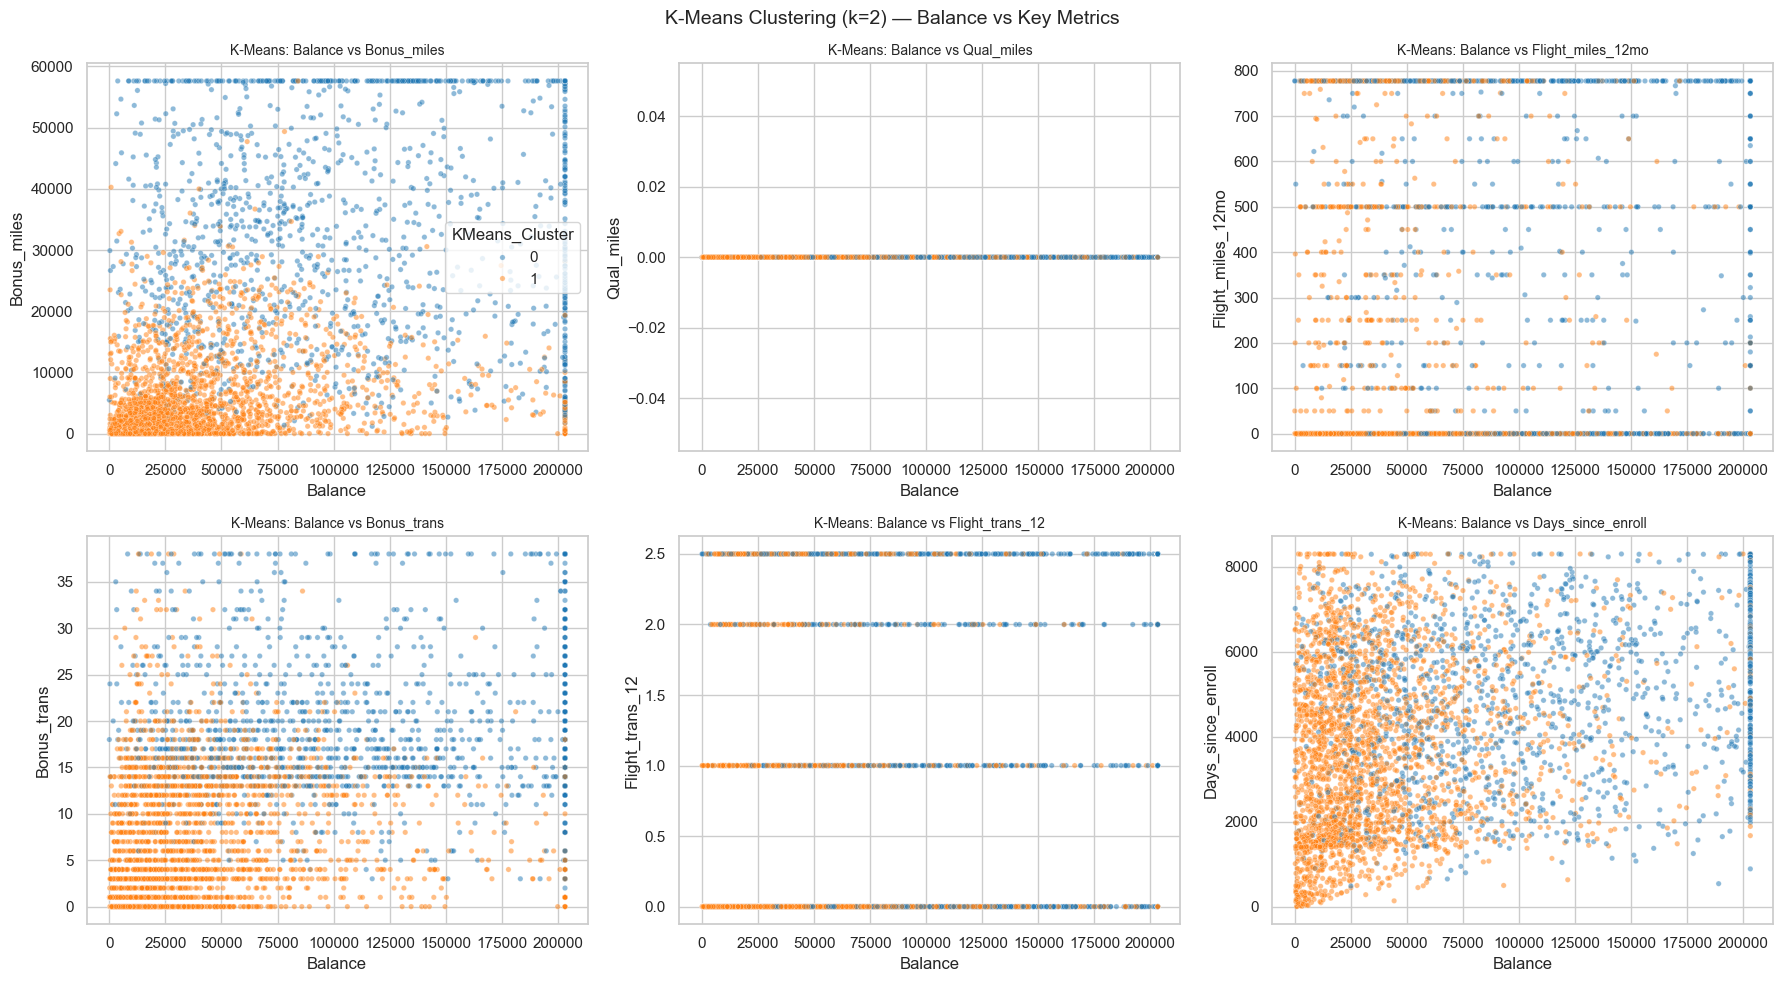

In [21]:
plot_pairs = [
    ("Balance", "Bonus_miles"),
    ("Balance", "Qual_miles"),
    ("Balance", "Flight_miles_12mo"),
    ("Balance", "Bonus_trans"),
    ("Balance", "Flight_trans_12"),
    ("Balance", "Days_since_enroll"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (xcol, ycol) in zip(axes, plot_pairs):
    sns.scatterplot(x=df[xcol], y=df[ycol], hue=df["KMeans_Cluster"],
                    palette="tab10", alpha=0.5, s=15, ax=ax, legend=(ax == axes[0]))
    ax.set_title(f"K-Means: {xcol} vs {ycol}", fontsize=10)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)

plt.suptitle(f"K-Means Clustering (k={best_k}) — Balance vs Key Metrics", fontsize=14)
plt.tight_layout()
plt.show()


In [22]:
# CLUSTER PROFILE ANALYSIS — K-Means
cluster_profile = df.groupby("KMeans_Cluster")[feature_cols].mean().round(1)
print("K-Means Cluster Profiles (mean of original features):")
print(cluster_profile.T.to_string())


K-Means Cluster Profiles (mean of original features):
KMeans_Cluster            0        1
Balance            107373.8  40254.1
Qual_miles              0.0      0.0
cc1_miles               3.4      1.3
cc2_miles               1.0      1.0
cc3_miles               1.0      1.0
Bonus_miles         34265.4   5243.1
Bonus_trans            19.3      7.2
Flight_miles_12mo     335.8     93.0
Flight_trans_12         1.1      0.3
Days_since_enroll    4913.7   3689.8
Award?                  0.7      0.2


# VISUALISATION 9 — Cluster Profile Heatmap

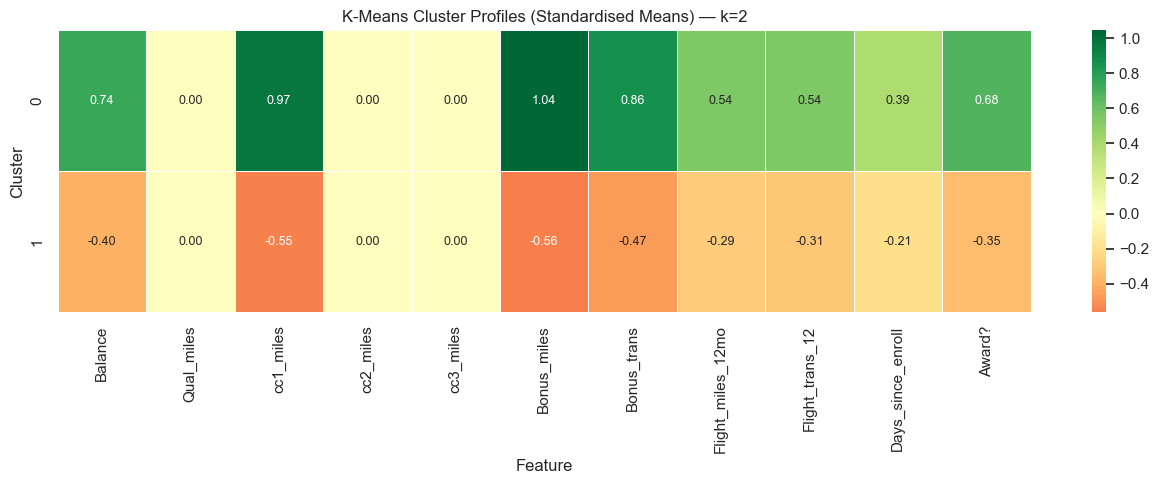

In [23]:
profile_scaled = pd.DataFrame(
    scaler.transform(cluster_profile),
    index=cluster_profile.index,
    columns=feature_cols
)

plt.figure(figsize=(13, 5))
sns.heatmap(profile_scaled, annot=True, cmap="RdYlGn", center=0,
            fmt=".2f", linewidths=0.5, annot_kws={"size": 9})
plt.title(f"K-Means Cluster Profiles (Standardised Means) — k={best_k}")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

# Task 4 — DBSCAN Clustering

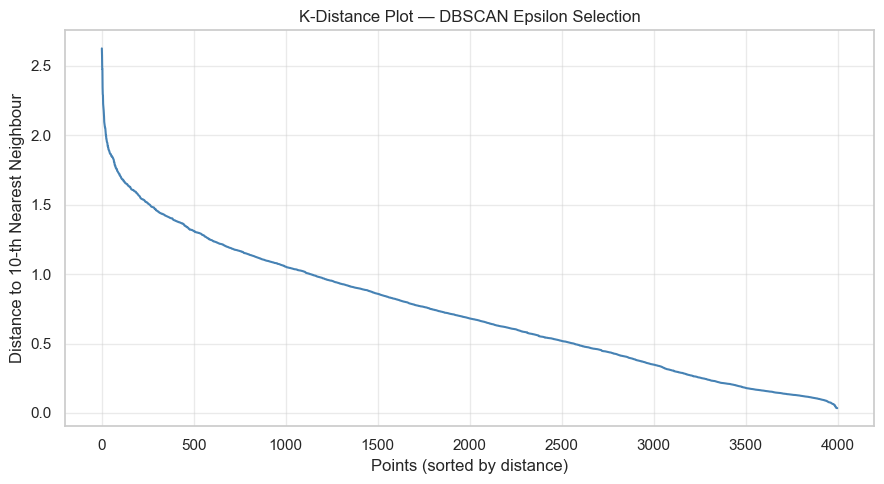

Look for the elbow (sharp bend) in the curve above.
The y-value at the elbow is a good starting epsilon.


In [24]:
from sklearn.neighbors import NearestNeighbors

min_samples = 10   # standard rule of thumb: min_samples >= n_features + 1
nbrs        = NearestNeighbors(n_neighbors=min_samples).fit(featss)
distances, _ = nbrs.kneighbors(featss)
k_distances  = np.sort(distances[:, -1])[::-1]   # sort descending

plt.figure(figsize=(9, 5))
plt.plot(k_distances, color="steelblue", linewidth=1.5)
plt.xlabel("Points (sorted by distance)")
plt.ylabel(f"Distance to {min_samples}-th Nearest Neighbour")
plt.title("K-Distance Plot — DBSCAN Epsilon Selection")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print("Look for the elbow (sharp bend) in the curve above.")
print("The y-value at the elbow is a good starting epsilon.")
## DBSCAN's epsilon defines the neighbourhood radius. Too small almost every point is noise. Too large and all points merge into one cluster. The k-distance elbow gives the natural density threshold where genuine clusters separate from noise.

In [25]:
# EPSILON TUNING — Silhouette Score vs Epsilon
print("DBSCAN Epsilon Tuning Results:")
print(f"{'eps':>6}  |  {'Clusters':>8}  |  {'Noise %':>8}  |  {'Silhouette':>10}")
print("-" * 45)

eps_scores  = {}
eps_range   = np.arange(0.5, 3.1, 0.25)

for eps in eps_range:
    db      = DBSCAN(eps=eps, min_samples=min_samples, metric="euclidean")
    labels  = db.fit_predict(featss)
    n_clust = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    noise_pct = n_noise / len(labels) * 100

    if n_clust >= 2:
        sil = silhouette_score(featss, labels)
        eps_scores[eps] = sil
        print(f"{eps:>6.2f}  |  {n_clust:>8d}  |  {noise_pct:>7.1f}%  |  {sil:>10.4f}")
    else:
        print(f"{eps:>6.2f}  |  {n_clust:>8d}  |  {noise_pct:>7.1f}%  |  {'N/A (< 2 clusters)':>10}")

if eps_scores:
    best_eps = max(eps_scores, key=eps_scores.get)
    print(f"\nBest epsilon : {best_eps:.2f}  (Silhouette={eps_scores[best_eps]:.4f})")
else:
    best_eps = 1.5
    print(f"\nNo valid epsilon found — defaulting to eps={best_eps}")


DBSCAN Epsilon Tuning Results:
   eps  |  Clusters  |   Noise %  |  Silhouette
---------------------------------------------
  0.50  |        11  |     55.8%  |     -0.2137
  0.75  |        17  |     33.4%  |     -0.0927
  1.00  |        12  |     17.3%  |     -0.0366
  1.25  |         4  |      5.7%  |      0.1278
  1.50  |         2  |      1.1%  |      0.2096
  1.75  |         2  |      0.2%  |      0.2122
  2.00  |         2  |      0.0%  |      0.2142
  2.25  |         1  |      0.0%  |  N/A (< 2 clusters)
  2.50  |         1  |      0.0%  |  N/A (< 2 clusters)
  2.75  |         1  |      0.0%  |  N/A (< 2 clusters)
  3.00  |         1  |      0.0%  |  N/A (< 2 clusters)

Best epsilon : 2.00  (Silhouette=0.2142)


In [26]:
# TRAIN DBSCAN WITH OPTIMAL EPSILON
dbscan   = DBSCAN(eps=best_eps, min_samples=min_samples, metric="euclidean")
db_labels = dbscan.fit_predict(featss)
df["DBSCAN_Cluster"] = db_labels

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db    = (db_labels == -1).sum()

print(f"DBSCAN (eps={best_eps:.2f}, min_samples={min_samples}):")
print(f"  Number of clusters : {n_clusters_db}")
print(f"  Noise points       : {n_noise_db}  ({n_noise_db/len(db_labels)*100:.1f}% of data)")
print(f"  Cluster sizes      :\n{pd.Series(db_labels).value_counts().sort_index().to_string()}")

if n_clusters_db >= 2:
    sil_db = silhouette_score(featss, db_labels)
    db_dbi = davies_bouldin_score(featss[db_labels != -1], db_labels[db_labels != -1])
    print(f"\n  Silhouette Score     : {sil_db:.4f}  (higher is better)")
    print(f"  Davies-Bouldin Index : {db_dbi:.4f}  (lower  is better)")


DBSCAN (eps=2.00, min_samples=10):
  Number of clusters : 2
  Noise points       : 1  (0.0% of data)
  Cluster sizes      :
-1       1
 0    2518
 1    1480

  Silhouette Score     : 0.2142  (higher is better)
  Davies-Bouldin Index : 1.8532  (lower  is better)


# VISUALISATION 10 — DBSCAN Cluster Scatter Plots

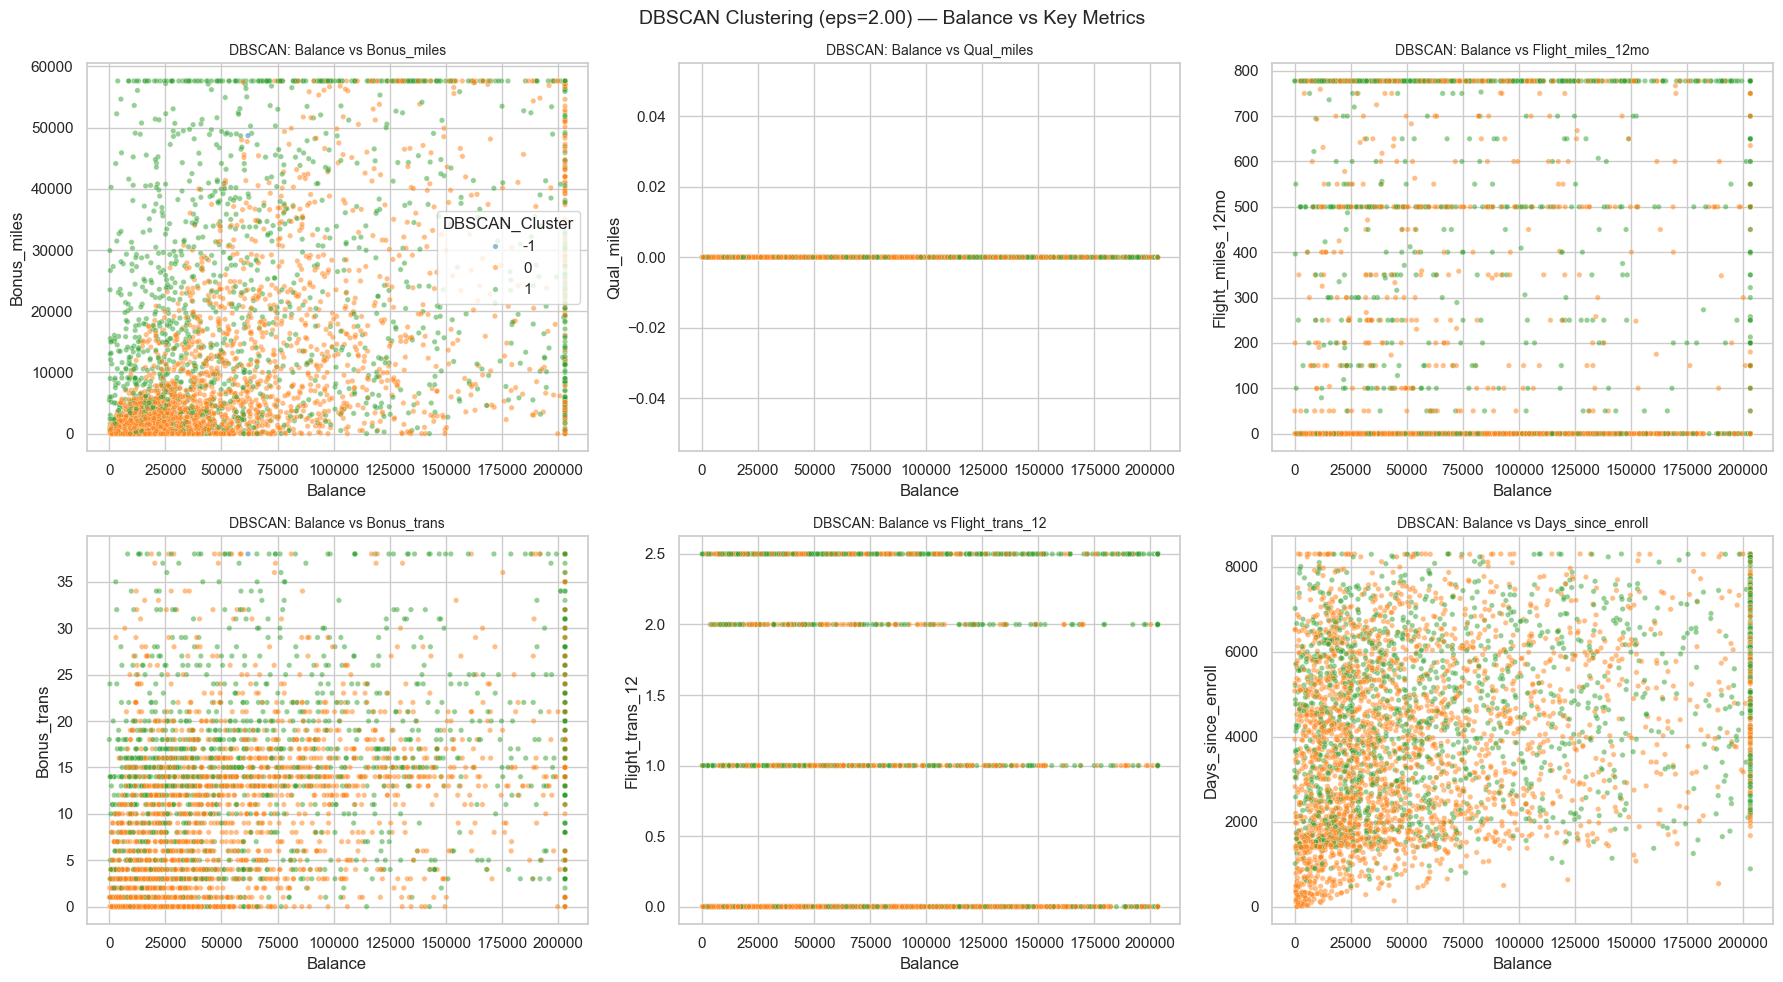

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (xcol, ycol) in zip(axes, plot_pairs):
    sns.scatterplot(x=df[xcol], y=df[ycol], hue=df["DBSCAN_Cluster"],
                    palette="tab10", alpha=0.5, s=15, ax=ax,
                    legend=(ax == axes[0]))
    ax.set_title(f"DBSCAN: {xcol} vs {ycol}", fontsize=10)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)

plt.suptitle(f"DBSCAN Clustering (eps={best_eps:.2f}) — Balance vs Key Metrics",
             fontsize=14)
plt.tight_layout()
plt.show()


# Task 5 — Evaluation, Comparison & Analysis

In [28]:
print("-" * 60)
print("       CLUSTERING PERFORMANCE COMPARISON")
print("-" * 60)
print(f"  Algorithm    : K-Means (k={best_k})         DBSCAN (eps={best_eps:.2f})")
print(f"  Clusters     : {best_k:<22d} {n_clusters_db}")
print(f"  Noise Points : {'0 (none)':22s} {n_noise_db}")
print(f"  Silhouette   : {sil_km:<22.4f} {sil_db if n_clusters_db>=2 else 'N/A'}")
print(f"  Davies-Bouldin: {db_km:<21.4f} {db_dbi if n_clusters_db>=2 else 'N/A'}")
print("-" * 60)

if n_clusters_db >= 2 and sil_km >= sil_db:
    print("VERDICT: K-Means produced better-separated clusters on this dataset.")
elif n_clusters_db >= 2:
    print("VERDICT: DBSCAN produced better-separated clusters on this dataset.")
else:
    print("VERDICT: K-Means is the primary method — DBSCAN found too few clusters.")

------------------------------------------------------------
       CLUSTERING PERFORMANCE COMPARISON
------------------------------------------------------------
  Algorithm    : K-Means (k=2)         DBSCAN (eps=2.00)
  Clusters     : 2                      2
  Noise Points : 0 (none)               1
  Silhouette   : 0.3191                 0.21420688840410834
  Davies-Bouldin: 1.4371                1.8531798667046817
------------------------------------------------------------
VERDICT: K-Means produced better-separated clusters on this dataset.


# VISUALISATION 11 — Side-by-Side Metric Comparison Bar Chart

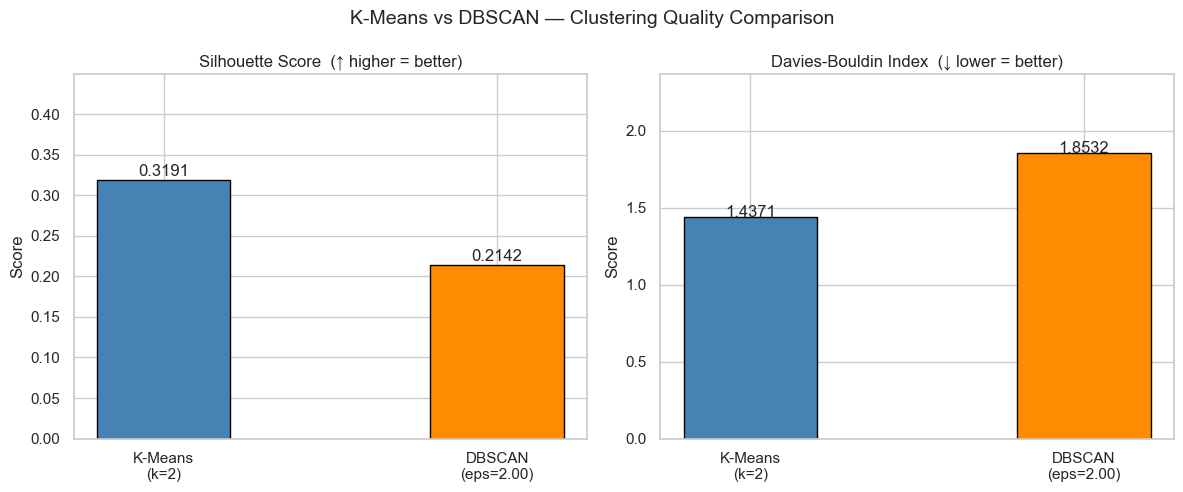

In [29]:
algos  = [f"K-Means\n(k={best_k})", f"DBSCAN\n(eps={best_eps:.2f})"]
sil_vals = [sil_km, sil_db if n_clusters_db >= 2 else 0]
db_vals  = [db_km,  db_dbi if n_clusters_db >= 2 else 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(algos, sil_vals, color=["steelblue", "darkorange"],
                   edgecolor="black", width=0.4)
for bar, val in zip(bars, sil_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f"{val:.4f}", ha="center", fontsize=12)
axes[0].set_title("Silhouette Score  (↑ higher = better)")
axes[0].set_ylim(0, max(sil_vals) * 1.25 + 0.05)
axes[0].set_ylabel("Score")

bars2 = axes[1].bar(algos, db_vals, color=["steelblue", "darkorange"],
                    edgecolor="black", width=0.4)
for bar, val in zip(bars2, db_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f"{val:.4f}", ha="center", fontsize=12)
axes[1].set_title("Davies-Bouldin Index  (↓ lower = better)")
axes[1].set_ylim(0, max(db_vals) * 1.25 + 0.05)
axes[1].set_ylabel("Score")

plt.suptitle("K-Means vs DBSCAN — Clustering Quality Comparison", fontsize=14)
plt.tight_layout()
plt.show()


In [30]:
# CLUSTER INTERPRETATION
print("K-Means Customer Segment Summary:")
print("-" * 60)

for cluster_id in sorted(df["KMeans_Cluster"].unique()):
    subset = df[df["KMeans_Cluster"] == cluster_id]
    n      = len(subset)
    print(f"\nCluster {cluster_id}  ({n} members, {n/len(df)*100:.1f}% of total):")
    print(f"  Avg Balance            : {subset['Balance'].mean():>10,.0f}")
    print(f"  Avg Bonus Miles        : {subset['Bonus_miles'].mean():>10,.0f}")
    print(f"  Avg Flight Miles (12mo): {subset['Flight_miles_12mo'].mean():>10,.0f}")
    print(f"  Avg Days Since Enroll  : {subset['Days_since_enroll'].mean():>10,.0f}")
    print(f"  Award Redeemers        : {subset['Award?'].mean()*100:>9.1f}%")


K-Means Customer Segment Summary:
------------------------------------------------------------

Cluster 0  (1401 members, 35.0% of total):
  Avg Balance            :    107,374
  Avg Bonus Miles        :     34,265
  Avg Flight Miles (12mo):        336
  Avg Days Since Enroll  :      4,914
  Award Redeemers        :      68.2%

Cluster 1  (2598 members, 65.0% of total):
  Avg Balance            :     40,254
  Avg Bonus Miles        :      5,243
  Avg Flight Miles (12mo):         93
  Avg Days Since Enroll  :      3,690
  Award Redeemers        :      20.2%


# Task 6 — Conclusion and Insights

#### K-Means worked well for segmenting airline members into clear groups based on balance, bonus miles, and flight activity. The Elbow Method and Silhouette Score helped pick the right number of clusters.

#### DBSCAN found similar groups and also flagged a small number of outlier customers who do not fit any pattern, which is useful for fraud detection or special follow-up.

#### K-Means is the better fit here because loyalty programme segments tend to be round and evenly sized. DBSCAN is a good complement for spotting unusual accounts.